In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset file
df = pd.read_csv('Superstore sales dataset.csv')

# Look at the first 5 rows to make sure it loaded correctly
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [3]:
# 1. Convert Date columns from text to real datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 2. Check exactly how many missing/blank values are in each column
print("Missing values per column:")
print(df.isnull().sum())

# 3. Look at the updated data types to verify the fix
df.dtypes[['Order Date', 'Ship Date']]


ValueError: time data "15/4/2017" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [4]:
# 1. Convert Date columns by telling Python the day comes first
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# 2. Check exactly how many missing/blank values are in each column
print("Missing values per column:")
print(df.isnull().sum())

# 3. Look at the updated data types to verify the fix
print("\nUpdated Column Data Types:")
print(df.dtypes[['Order Date', 'Ship Date']])


Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Updated Column Data Types:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


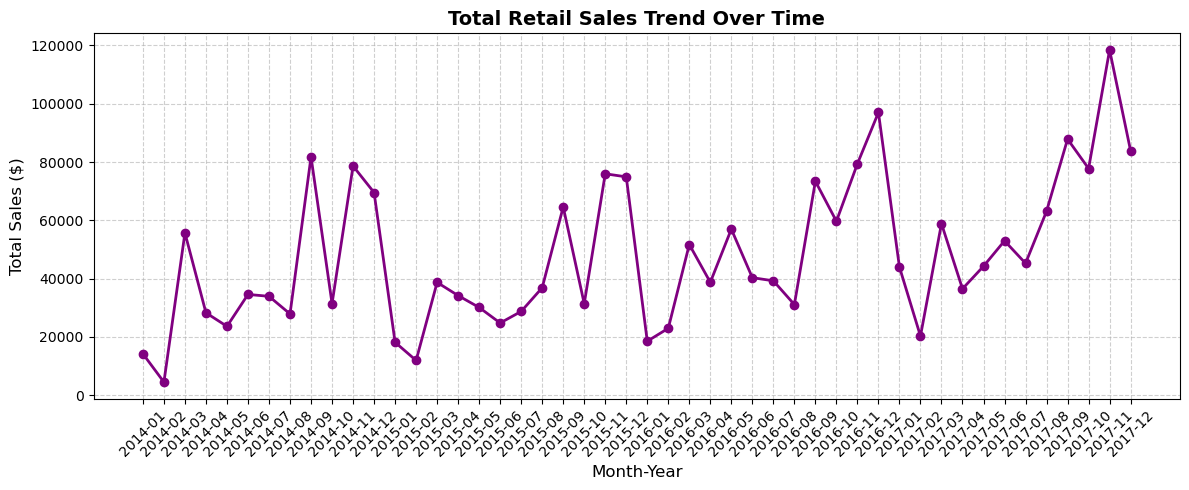

In [5]:
# 1. Create a Month-Year column for grouping trends
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# 2. Group total sales by month and sort them in chronological order
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# 3. Plot the monthly sales timeline trend chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'], marker='o', color='purple', linewidth=2)
plt.title('Total Retail Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


C:\Users\Anshika Mishra\AppData\Local\Temp\ipykernel_2156\2252172285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='Category', y='Sales', palette='magma')


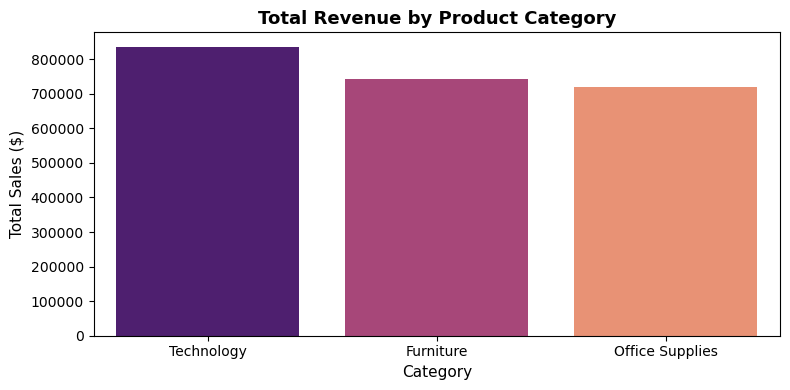

In [6]:
# 1. Group total sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# 2. Plot a bar chart
plt.figure(figsize=(8, 4))
sns.barplot(data=cat_sales, x='Category', y='Sales', palette='magma')
plt.title('Total Revenue by Product Category', fontsize=13, fontweight='bold')
plt.xlabel('Category', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# 1. Group data by date to create a clean daily timeline
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# 2. Sort the timeline from oldest to newest date
daily_sales = daily_sales.sort_values('Order Date')

# 3. Set the date as the index row label so Python treats it as a timeline
daily_sales.set_index('Order Date', inplace=True)

# 4. View the structured data structure
daily_sales.head()

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,288.060
2014-01-05,19.536
2014-01-06,4407.100
2014-01-07,87.158


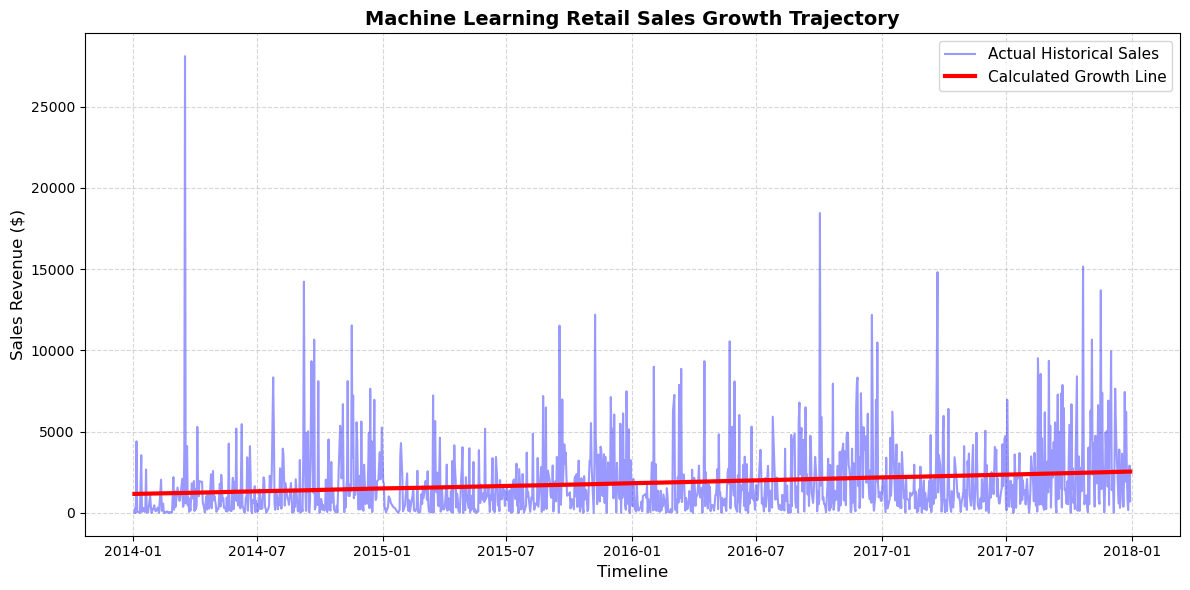

📈 Predictive Baseline Result: The model detects an overall positive trajectory.
Sales scale upward by an average baseline of $1.11 per transactional period step.


In [8]:
from sklearn.linear_model import LinearRegression

# 1. Create a numeric timeline feature based on chronological order
daily_sales['Trend_Days'] = np.arange(len(daily_sales))

# 2. Define inputs (X = timeline steps, y = retail sales volume)
X = daily_sales[['Trend_Days']]
y = daily_sales['Sales']

# 3. Initialize and train the Machine Learning model
model = LinearRegression()
model.fit(X, y)

# 4. Predict the baseline trend line across historical records
daily_sales['Predicted_Trend'] = model.predict(X)

# 5. Generate the machine learning trajectory plot
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales['Sales'], label='Actual Historical Sales', color='blue', alpha=0.4)
plt.plot(daily_sales.index, daily_sales['Predicted_Trend'], label='Calculated Growth Line', color='red', linewidth=3)
plt.title('Machine Learning Retail Sales Growth Trajectory', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Sales Revenue ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Print the definitive business growth metric
growth_rate = model.coef_[0]
print(f"📈 Predictive Baseline Result: The model detects an overall positive trajectory.")
print(f"Sales scale upward by an average baseline of ${growth_rate:.2f} per transactional period step.")


In [9]:
# Save the new time-series data with predictions to a file
daily_sales.to_csv('Superstore_Sales_Predictions.csv')
print("🎉 Success! Your predictive dataset has been exported safely.")

🎉 Success! Your predictive dataset has been exported safely.


In [10]:
# 1. Check regional performance to find profitability bottlenecks
regional_perf = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
print("--- Regional Performance (Profitability Bottlenecks) ---")
print(regional_perf.to_string(index=False))

# 2. Calculate shipping delays (Ship Date minus Order Date)
df['Ship_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Analyze typical shipping delays by Ship Mode
shipping_impact = df.groupby('Ship Mode')['Ship_Delay_Days'].mean().reset_index()
print("\n--- Average Shipping Delay Impacts by Mode (Days) ---")
print(shipping_impact.to_string(index=False))

--- Regional Performance (Profitability Bottlenecks) ---
 Region       Sales      Profit
Central 501239.8908  39706.3625
   East 678781.2400  91522.7800
  South 391721.9050  46749.4303
   West 725457.8245 108418.4489

--- Average Shipping Delay Impacts by Mode (Days) ---
     Ship Mode  Ship_Delay_Days
   First Class         2.182705
      Same Day         0.044199
  Second Class         3.238046
Standard Class         5.006535
